In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torch.nn.functional as F
from transformers import AutoTokenizer
import os

import random
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import v2
import numpy as np

In [180]:
images_path = []
classes = []
all_classes  = []
targets = []
main_path = "../data/animals"

for path_name, foldernames, filenames in os.walk(main_path):
    for file_name in filenames:
        file_path = os.path.join(path_name, file_name)
        images_path.append(file_path)
        all_classes.append(os.path.basename(path_name))

classes = sorted(set(all_classes))
len(images_path)

print(f"Liczba zdjec w folderach {len(images_path)}")
print(f"Klasy: {len(classes)}")


Liczba zdjec w folderach 5400
Klasy: 90


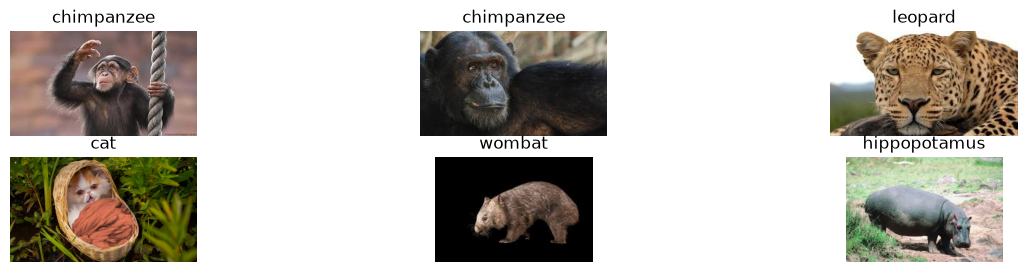

In [181]:
plt.figure(figsize=(15, 3))
for i in range(6):
    plt.subplot(2, 3, i+1)
    image_path = random.choice(images_path)
    image = Image.open(image_path)
    plt.imshow(image)
    plt.title(image_path.split("/")[3])
    plt.axis("off")

In [182]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
from pathlib import Path
from torchvision.transforms import v2

class CLIPDataset(Dataset):
    def __init__(self, all_images_paths, captions, tokenizer, transform=None):
        self.images_paths = all_images_paths
        self.captions = captions
        self.tokenizer = tokenizer
        self.targets = [Path(path).parent.name for path in self.images_paths]

        if transform is not None:
            self.transform = transform
        else:
            self.transform = v2.Compose([
                v2.Resize(256),
                v2.CenterCrop(224),
                v2.RandomHorizontalFlip(),
                v2.RandomRotation(degrees=20),
                v2.ColorJitter(
                    brightness=0.2,
                    contrast=0.2,
                    saturation=0.2,
                    hue=0.1
                ),
                v2.ToImage(),
                v2.ToDtype(torch.float32, scale=True),
                v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return len(self.images_paths)

    def __getitem__(self, index):
        image_path = self.images_paths[index]
        img = Image.open(image_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        text = str(self.captions[index]['caption'])
        tokens = self.tokenizer(
            text,
            max_length=32,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        input_ids = tokens['input_ids'].squeeze(0)
        attention_mask = tokens['attention_mask'].squeeze(0)

        return img, input_ids, attention_mask

In [183]:
import json

with open("../data/dataset_captions.json", "r", encoding="utf-8") as file:
    data = json.load(file)

In [184]:
from torchvision import models
from transformers import AutoModel

class ImageEmbeddingTower(nn.Module):
    def __init__(self, num_dims):
        super().__init__()
        self.num_dims = num_dims

        model_weights = models.EfficientNet_B0_Weights.DEFAULT
        self.backbone = models.efficientnet_b0(weights=model_weights)

        for params in self.backbone.parameters():
            params.requires_grad = False

        self.num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()


        self.embedding_head = nn.Sequential(
            nn.Linear(self.num_features, self.num_dims),
            nn.LayerNorm(self.num_dims)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.embedding_head(features)

class TextEmbeddingTower(nn.Module):
    def __init__(self, num_dims):
        super().__init__()
        self.num_dims = num_dims

        self.text_encoder_model = AutoModel.from_pretrained("distilbert-base-uncased", attn_implementation="eager")
        self.num_bert_feature = self.text_encoder_model.config.hidden_size

        for params in self.text_encoder_model.parameters():
            params.requires_grad = False

        self.text_projection = nn.Sequential(
            nn.Linear(self.num_bert_feature, self.num_dims),
            nn.LayerNorm(self.num_dims)
        )

    def mean_pooling(self, last_hidden_state, attention_mask):

        input_mask_expanded = (
            attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        )

        sum_embedding = torch.sum(last_hidden_state * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        return sum_embedding / sum_mask

    def forward(self, input_ids, attention_mask):
        text_outputs = self.text_encoder_model(input_ids, attention_mask)
        pooled_output = self.mean_pooling(last_hidden_state=text_outputs.last_hidden_state, attention_mask=attention_mask)

        projected_embd = self.text_projection(pooled_output)

        return projected_embd

class CLIPModel(nn.Module):
    def __init__(self, num_dims):
        super().__init__()
        self.image_tower = ImageEmbeddingTower(num_dims)
        self.text_tower = TextEmbeddingTower(num_dims)

    def forward(self, x, input_ids, attention_mask):
        image_embedding = self.image_tower(x)
        text_embedding = self.text_tower(input_ids, attention_mask)

        img_norm = F.normalize(image_embedding, p=2, dim=-1)
        text_norm = F.normalize(text_embedding, p=2, dim=-1)
        return img_norm, text_norm
    


class ClipLoss(nn.Module):
    def __init__(self, init_temp=0.07):
        super().__init__()
        self.loss = nn.CrossEntropyLoss()
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / init_temp))

    def forward(self, img_emb, text_emb):

        logit_scale = torch.clamp(self.logit_scale.exp(), max=100)
        logits = logit_scale * (img_emb @ text_emb.T)

        batch_size = img_emb.shape[0]
        targets = torch.arange(batch_size, device=img_emb.device)

        loss_img = self.loss(logits, targets)
        loss_text = self.loss(logits.T, targets)

        return (loss_img + loss_text) / 2

criterion = ClipLoss()
CLIPModel = CLIPModel(num_dims=256)

optimizer = torch.optim.AdamW(CLIPModel.parameters(), lr=1e-4)
device = "mps" if torch.backends.mps.is_available() else "cpu"

CLIPModel.to(device)

        

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7121.42it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIPModel(
  (image_tower): ImageEmbeddingTower(
    (backbone): EfficientNet(
      (features): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): Sequential(
          (0): MBConv(
            (block): Sequential(
              (0): Conv2dNormActivation(
                (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
                (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
                (2): SiLU(inplace=True)
              )
              (1): SqueezeExcitation(
                (avgpool): AdaptiveAvgPool2d(output_size=1)
                (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
                (fc2): Conv2d(8, 32, kernel_

In [185]:
from collections import defaultdict
from torch.utils.data import Sampler, DataLoader

class HardNegativeBatchSampler(Sampler):
    def __init__(self, labels, batch_size, samples_per_class):
        self.labels = labels
        self.batch_size = batch_size
        self.samples_per_class = samples_per_class

        self.classes_per_batch = batch_size // samples_per_class

        self.class_to_indices = defaultdict(list)
        for idx, label in enumerate(labels):
            self.class_to_indices[label].append(idx)

        self.classes = list(self.class_to_indices.keys())
        self.num_batches = len(labels) // batch_size

    def __iter__(self):
        for _ in range(self.num_batches):
            batch_indicies = []
            selected_classes = random.sample(self.classes, self.classes_per_batch)

            for cls in selected_classes:
                indices = self.class_to_indices[cls]
                if len(indices) >= self.samples_per_class:
                    sampled = random.sample(indices, self.samples_per_class)
                else:
                    sampled = random.choices(indices, k=self.samples_per_class)

                batch_indicies.extend(sampled)

            random.shuffle(batch_indicies)

            yield batch_indicies

    def __len__(self):
        return self.num_batches

In [186]:

dataset = CLIPDataset(images_path, data, tokenizer)
all_labels = dataset.targets

custom_sampler = HardNegativeBatchSampler(
    labels=all_labels,
    batch_size=32,
    samples_per_class=2
)

dataloader = DataLoader(
    dataset,
    batch_sampler=custom_sampler,
    num_workers=0
)


In [187]:
from tqdm import tqdm
def clip_training(CLIPModel, loss_function, optimizer, loader, device):
    CLIPModel.to(device)
    CLIPModel.train()

    CLIPModel.image_tower.backbone.features[:-2].eval()

    total_loss = 0.0
    for images, input_ids, attention_mask in tqdm(loader):
        images, input_ids, attention_mask = images.to(device), input_ids.to(device), attention_mask.to(device)

        optimizer.zero_grad()
        img_emb, text_emb = CLIPModel(images, input_ids, attention_mask)
        loss = loss_function(img_emb, text_emb)
        loss.backward()

        torch.nn.utils.clip_grad_norm(CLIPModel.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    loss_batch = total_loss / len(loader)
    return loss_batch

In [188]:
epochs = 20
best_loss = float('inf')
for epoch in range(epochs):
    clip_loss = clip_training(CLIPModel, criterion, optimizer, dataloader, device)

    print(f"Epoch: {epoch}, Loss: {clip_loss}")

    if best_loss > clip_loss:
        best_loss = clip_loss
        torch.save(CLIPModel.state_dict(), "../models/best_model.pth")


  0%|          | 0/168 [00:00<?, ?it/s]/var/folders/xn/8ns0kkn125q6gt7wmrzx36k80000gn/T/ipykernel_17531/2437021720.py:17: FutureWarning: `torch.nn.utils.clip_grad_norm` is now deprecated in favor of `torch.nn.utils.clip_grad_norm_`.
  torch.nn.utils.clip_grad_norm(CLIPModel.parameters(), max_norm=1.0)
100%|██████████| 168/168 [00:58<00:00,  2.88it/s]


Epoch: 0, Loss: 2.2318535773527053


100%|██████████| 168/168 [00:59<00:00,  2.82it/s]


Epoch: 1, Loss: 1.2942747182789303


100%|██████████| 168/168 [00:59<00:00,  2.84it/s]


...

Epoch: 17, Loss: 0.3927698909704174


100%|██████████| 168/168 [01:18<00:00,  2.14it/s]


Epoch: 18, Loss: 0.3913141540473416


100%|██████████| 168/168 [01:15<00:00,  2.21it/s]


Epoch: 19, Loss: 0.36976561775164946


In [189]:


for params in CLIPModel.image_tower.backbone.features[-2:].parameters():
    params.requires_grad = True

for layer in CLIPModel.text_tower.text_encoder_model.transformer.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

backbone_params = []
head_params = []

for name, param in CLIPModel.image_tower.backbone.named_parameters():
    if param.requires_grad:
        backbone_params.append(param)

for name, param in CLIPModel.text_tower.text_encoder_model.transformer.named_parameters():
    if param.requires_grad:
        backbone_params.append(param)

head_params.extend(list(CLIPModel.image_tower.embedding_head.parameters()))
head_params.extend(list(CLIPModel.text_tower.text_projection.parameters()))

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": 1e-5, "weight_decay": 1e-2},
    {"params": head_params, "lr": 1e-4, "weight_decay": 1e-4},
    {"params": [criterion.logit_scale], "lr": 1e-4}
])



In [194]:
epochs = 10
best_loss = float('inf')
for epoch in range(epochs):
    clip_loss = clip_training(CLIPModel, criterion, optimizer, dataloader, device)

    print(f"Epoch: {epoch}, Loss: {clip_loss}")

    if best_loss > clip_loss:
        best_loss = clip_loss
        torch.save(CLIPModel.state_dict(), "../models/best_model.pth")


  0%|          | 0/168 [00:00<?, ?it/s]/var/folders/xn/8ns0kkn125q6gt7wmrzx36k80000gn/T/ipykernel_17531/2437021720.py:17: FutureWarning: `torch.nn.utils.clip_grad_norm` is now deprecated in favor of `torch.nn.utils.clip_grad_norm_`.
  torch.nn.utils.clip_grad_norm(CLIPModel.parameters(), max_norm=1.0)
100%|██████████| 168/168 [01:12<00:00,  2.31it/s]


Epoch: 0, Loss: 0.17327028947571912


100%|██████████| 168/168 [01:25<00:00,  1.96it/s]


Epoch: 1, Loss: 0.16889303261857658


100%|██████████| 168/168 [01:32<00:00,  1.83it/s]


...

Epoch: 6, Loss: 0.13651306399454674


100%|██████████| 168/168 [01:36<00:00,  1.73it/s]


Epoch: 7, Loss: 0.13704488945326634


 55%|█████▍    | 92/168 [00:56<00:46,  1.64it/s]


KeyboardInterrupt: 

In [191]:
CLIPModel.load_state_dict(torch.load("../models/best_model.pth"))
test_transform = v2.Compose([
    v2.Resize(256),
    v2.CenterCrop(224),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

def generate_clip_dataset(clip_model, device):
    clip_model.eval()
    database = []

    with torch.no_grad():
        for images in images_path:
            img = Image.open(images).convert("RGB")
            img_t = test_transform(img)
            img = img_t.unsqueeze(0).to(device)

            img_emb = clip_model.image_tower(img)
            img_emb = F.normalize(img_emb, p=2, dim=-1)
            database.append(img_emb)

    return torch.cat(database)
baza_wek = generate_clip_dataset(CLIPModel, device)
baza_wek = baza_wek.to(device)

In [192]:
def question(question, database, images_path, tokenizer, clip_model, device):
    tokens = tokenizer(
        question,
        max_length=256,
        truncation=True,
        padding=True,
        return_tensors="pt"
    ).to(device)

    clip_model.eval()
    with torch.no_grad():
        text_emb = clip_model.text_tower(tokens['input_ids'], tokens['attention_mask'])
        text_emb = F.normalize(text_emb, p=2, dim=-1)
        scores = (text_emb @ database.T).squeeze(0)

        top_values, top_indices = torch.topk(scores, k=6)

        result = [images_path[idx.item()] for idx in top_indices]

        return result, top_values

result, scores = question("a dog catching a frisbee in the air", baza_wek, images_path, tokenizer, CLIPModel, device)


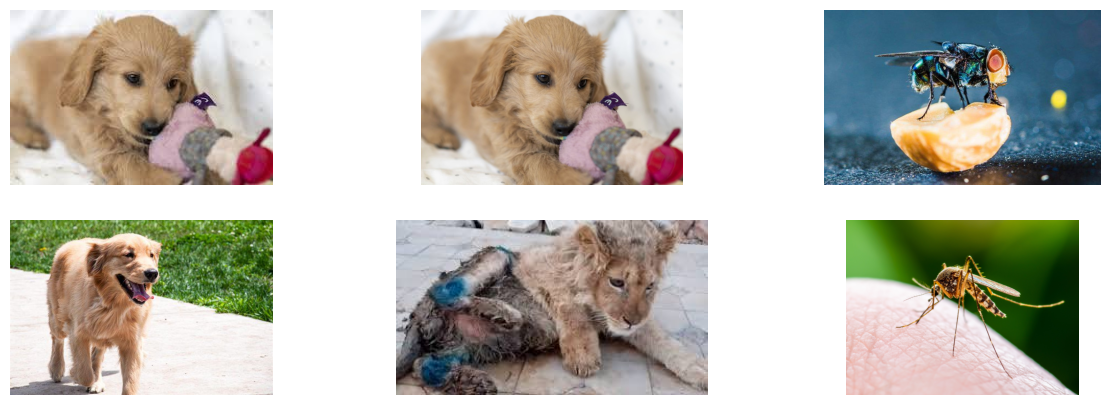

In [193]:
plt.figure(figsize=(15, 5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    img = Image.open(result[i])
    plt.imshow(img)
    plt.axis("off")
        
        